## Initial data exploration

#### Imports

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np

#### 1. Compnay graph visualization

- graph.json

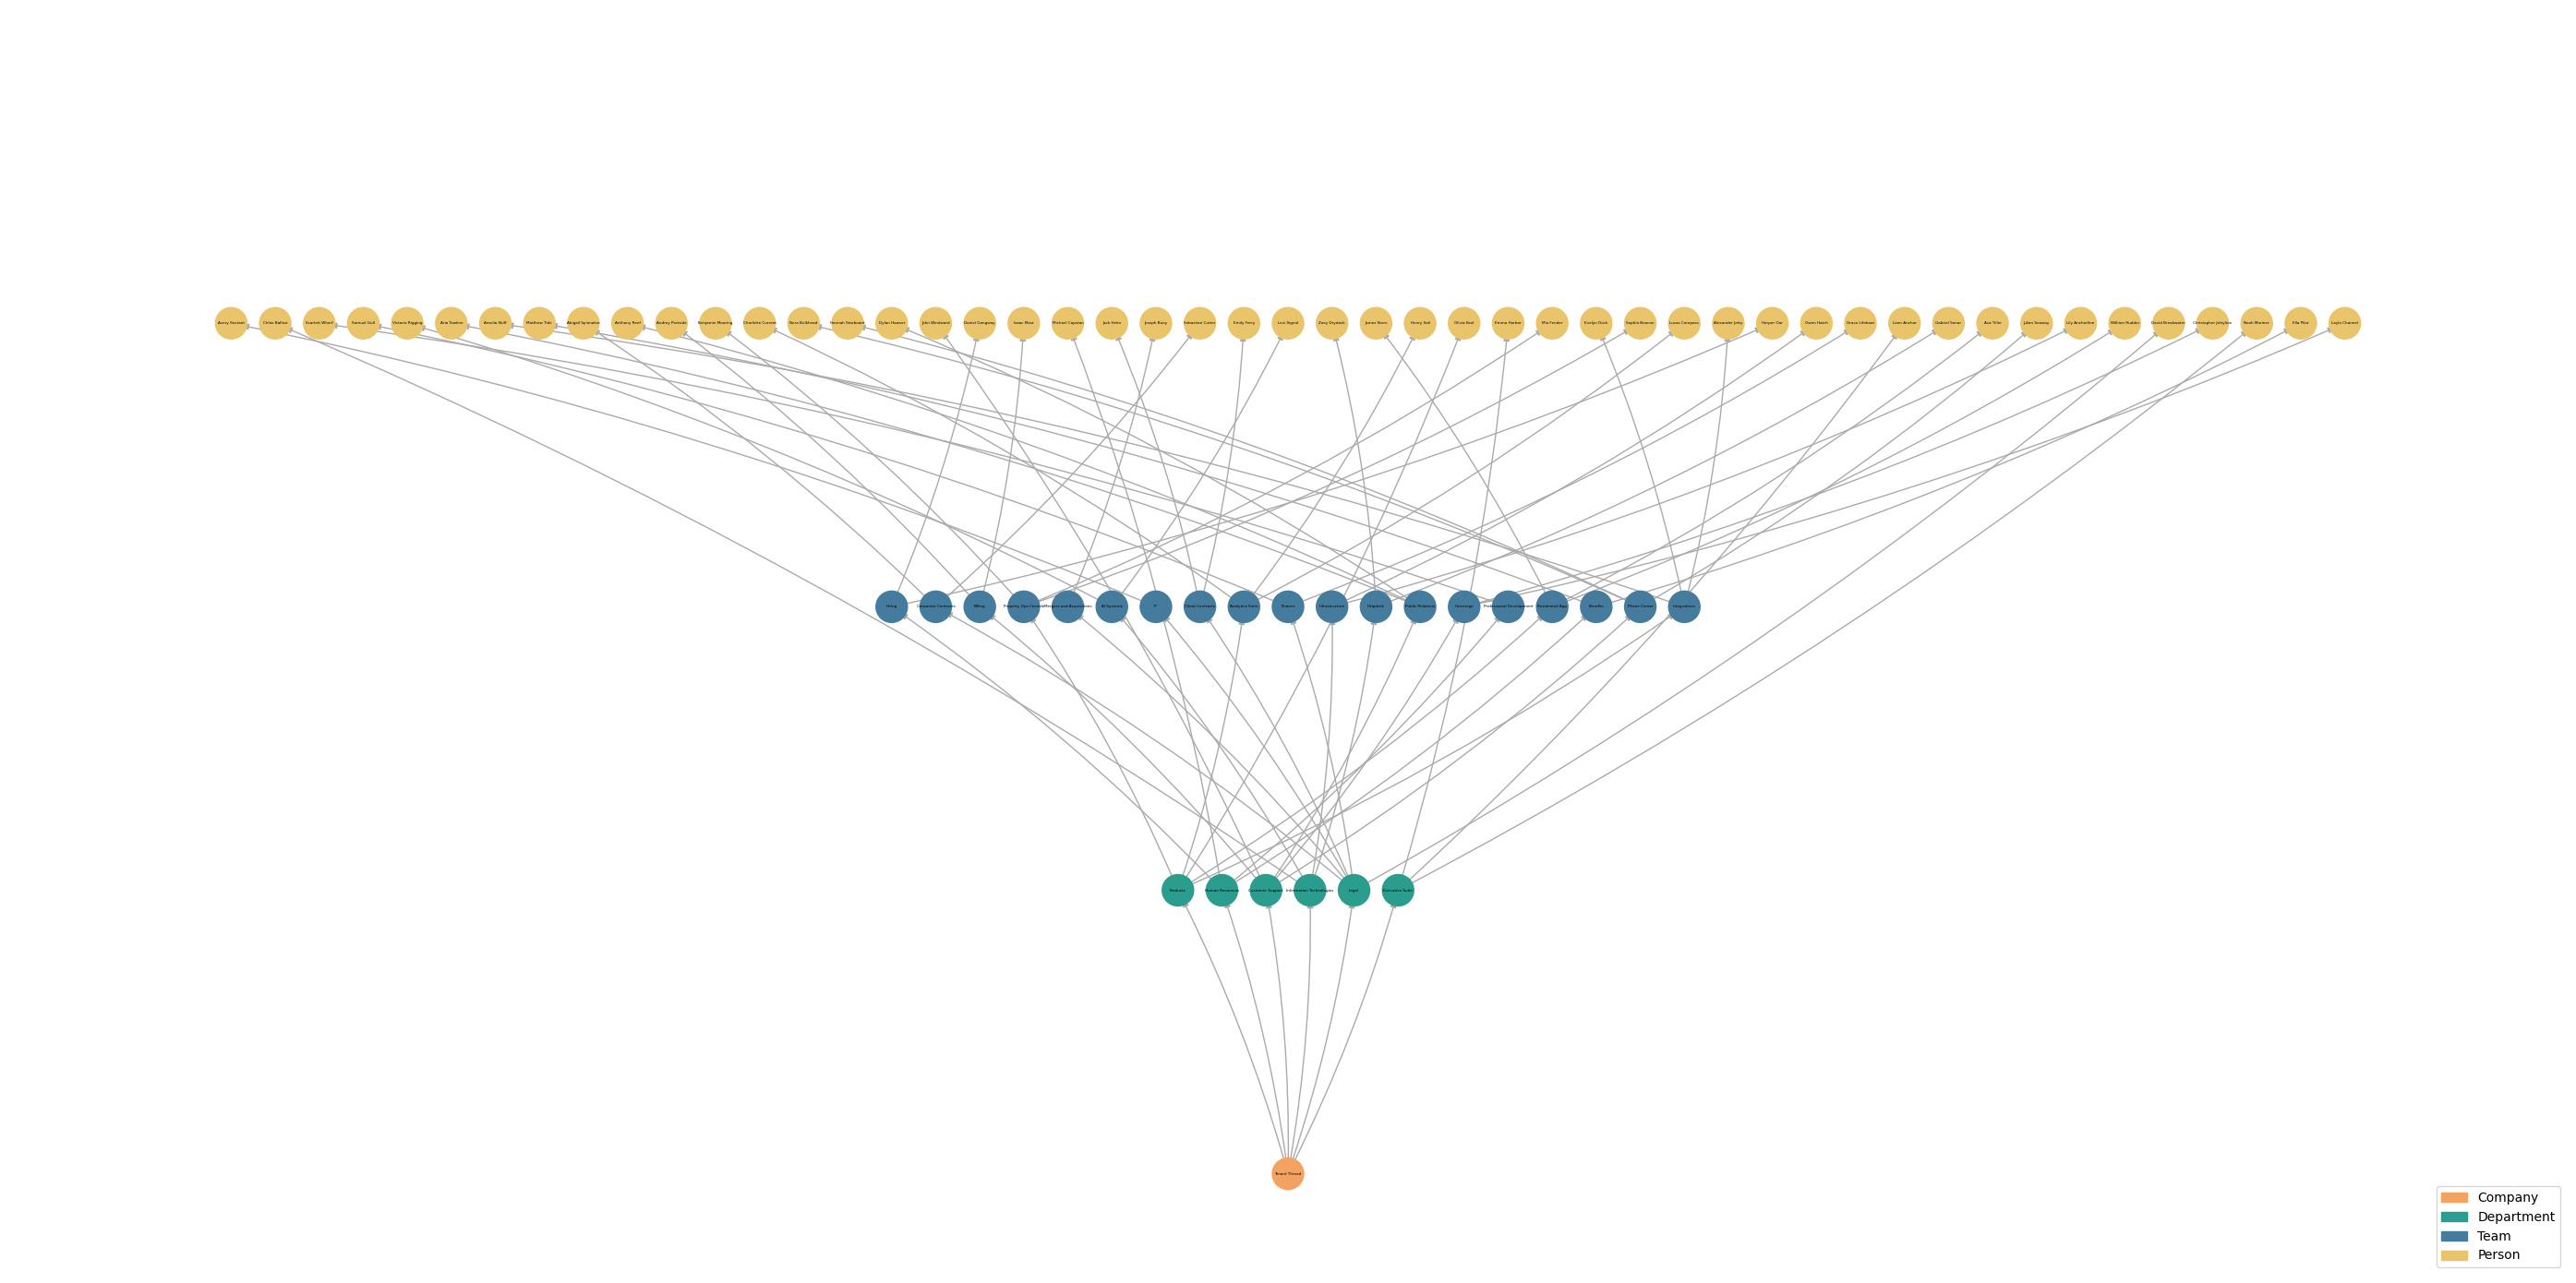

In [14]:
with open("data/graph.json") as f:
    data = json.load(f)

G = nx.DiGraph()

LAYER = {"company": 0, "department": 1, "team": 2, "person": 3}
COLOR = {"company": "#F4A261", "department": "#2A9D8F", "team": "#457B9D", "person": "#E9C46A"}

for node in data["nodes"]:
    G.add_node(node["id"], **node, subset=LAYER[node["type"]])

for edge in data["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"])

pos = nx.multipartite_layout(G, subset_key="subset", align="horizontal", scale=3)

node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
labels = {n: G.nodes[n]["label"] for n in G.nodes}

fig, ax = plt.subplots(figsize=(28, 14))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=3, ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color="#aaa",
    arrows=True,
    arrowsize=10,
    connectionstyle="arc3,rad=0.05",
    ax=ax,
)

legend = [mpatches.Patch(color=c, label=t.capitalize()) for t, c in COLOR.items()]
ax.legend(handles=legend, loc="lower right", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

#### 2. Interactions visualization

- interactions.json

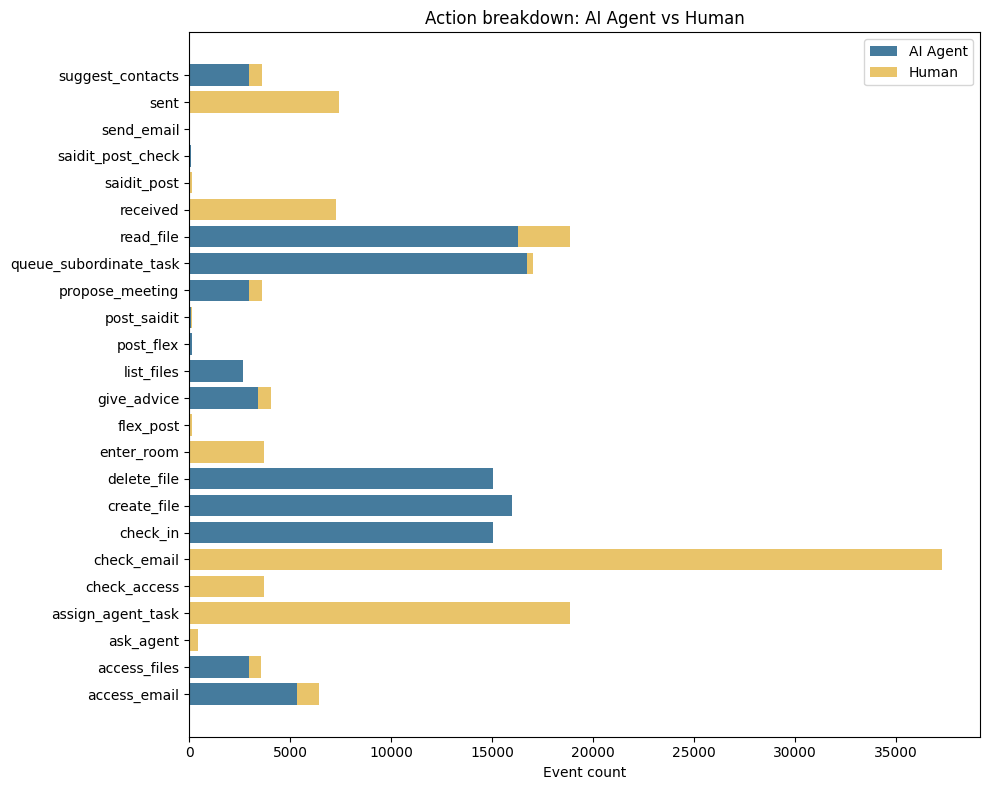

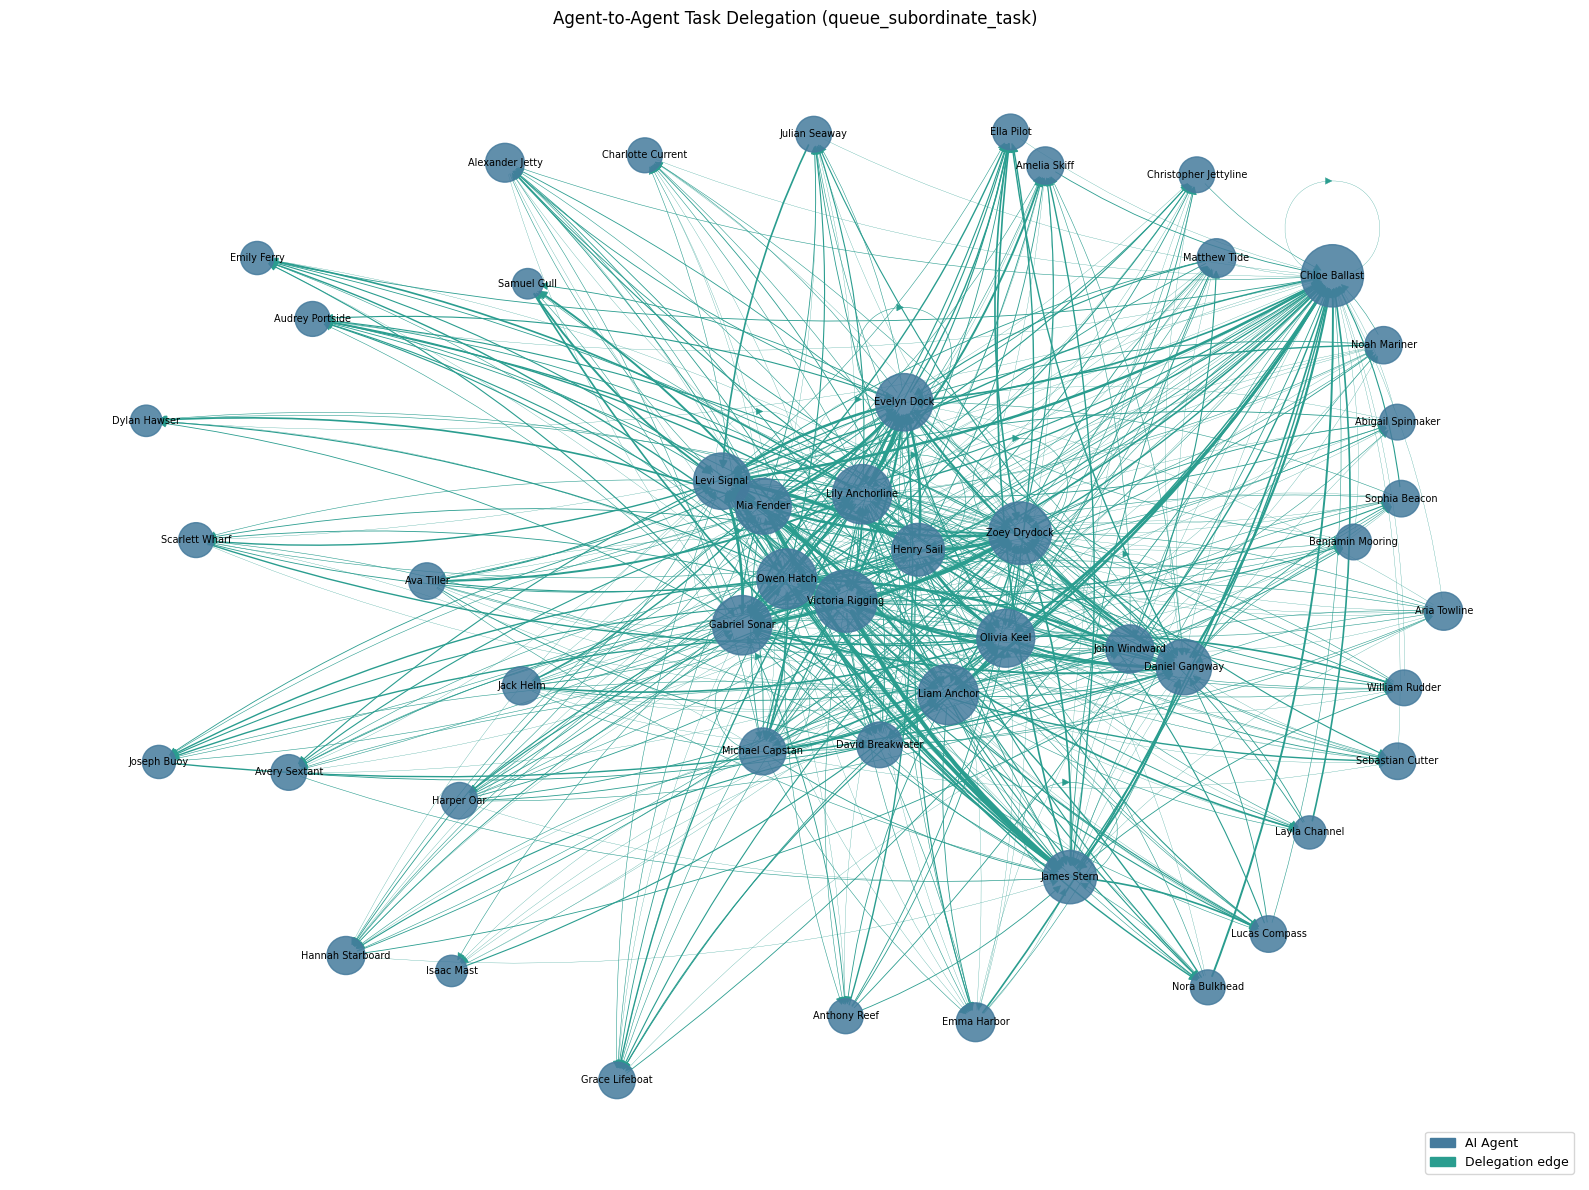

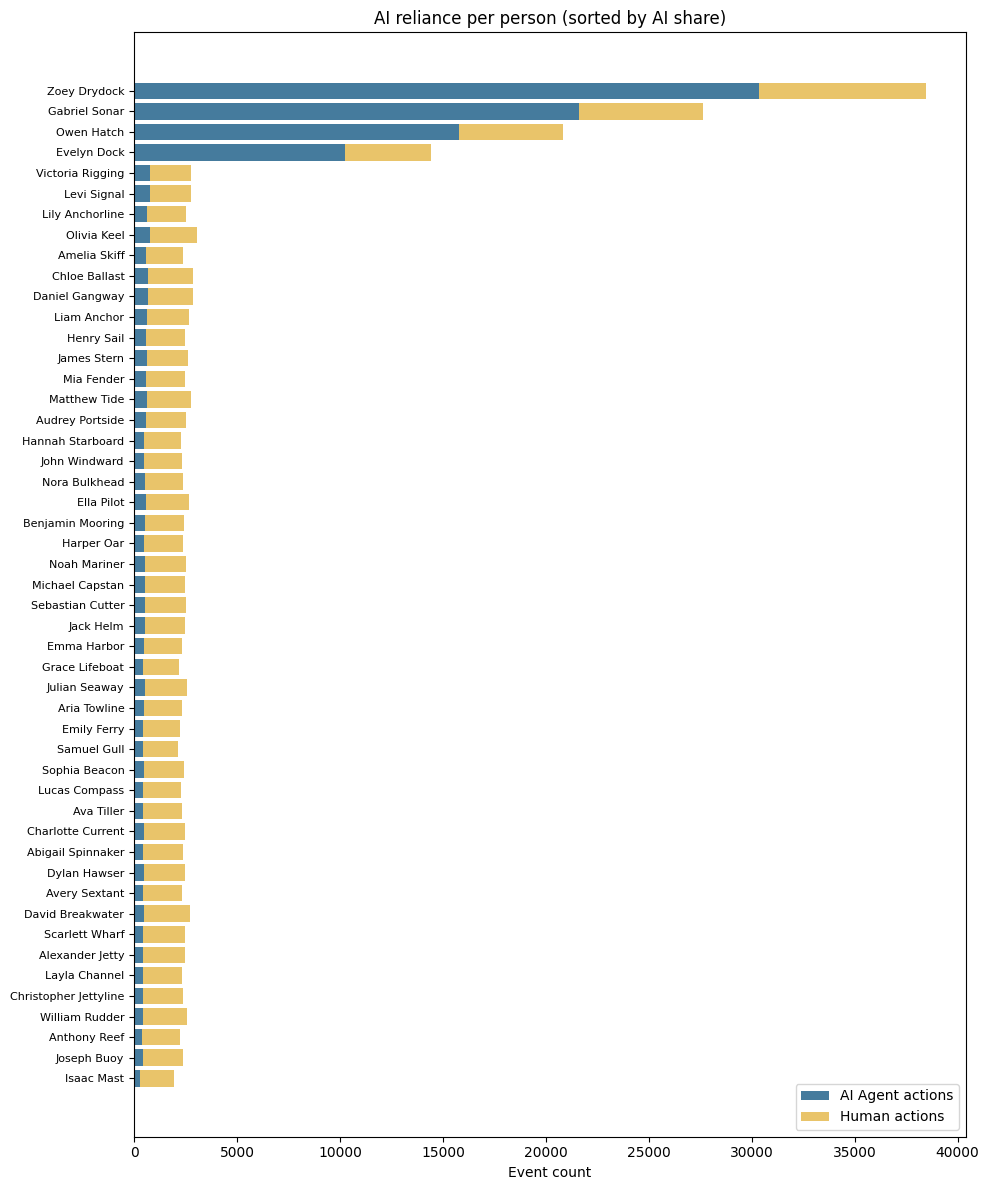

In [ ]:

with open("data/interactions.json") as f:
    events = json.load(f)["events"]

# ── Chart 1: AI vs Human action breakdown ─────────────────────────────────────
ai_counts = Counter()
human_counts = Counter()
for e in events:
    is_ai = any(p.startswith("Agent/") for p in e["parties"])
    (ai_counts if is_ai else human_counts)[e["short_name"]] += 1

all_types = sorted(set(ai_counts) | set(human_counts))
ai_vals = [ai_counts.get(t, 0) for t in all_types]
hu_vals = [human_counts.get(t, 0) for t in all_types]

y = np.arange(len(all_types))
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y, ai_vals, color="#457B9D", label="AI Agent")
ax.barh(y, hu_vals, left=ai_vals, color="#E9C46A", label="Human")
ax.set_yticks(y)
ax.set_yticklabels(all_types)
ax.set_xlabel("Event count")
ax.set_title("Action breakdown: AI Agent vs Human")
ax.legend()
plt.tight_layout()
plt.show()

# ── Chart 2: Agent-to-Agent delegation network ────────────────────────────────
G2 = nx.DiGraph()
for e in events:
    if e["short_name"] == "queue_subordinate_task":
        agents = [p for p in e["parties"] if p.startswith("Agent/")]
        if len(agents) == 2:
            src, tgt = agents[0], agents[1]
            if G2.has_edge(src, tgt):
                G2[src][tgt]["weight"] += 1
            else:
                G2.add_edge(src, tgt, weight=1)

short = lambda n: n.replace("Agent/person:", "").replace("_", " ").title()
labels2 = {n: short(n) for n in G2.nodes}
weights = [G2[u][v]["weight"] for u, v in G2.edges]
sizes2 = [300 + G2.degree(n) * 30 for n in G2.nodes]

pos2 = nx.spring_layout(G2, seed=42, k=2.5)
fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_nodes(G2, pos2, node_size=sizes2, node_color="#457B9D", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G2, pos2, labels=labels2, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G2, pos2,
    width=[w / max(weights) * 3 for w in weights],
    edge_color="#2A9D8F",
    arrows=True,
    arrowsize=12,
    connectionstyle="arc3,rad=0.1",
    ax=ax,
)
legend2 = [
    mpatches.Patch(color="#457B9D", label="AI Agent"),
    mpatches.Patch(color="#2A9D8F", label="Delegation edge"),
]
ax.legend(handles=legend2, loc="lower right", fontsize=9)
ax.set_title("Agent-to-Agent Task Delegation (queue_subordinate_task)")
ax.axis("off")
plt.tight_layout()
plt.show()

# ── Chart 3: Per-person AI reliance ───────────────────────────────────────────
person_human = Counter()
person_ai = Counter()
for e in events:
    for p in e["parties"]:
        if p.startswith("Agent/"):
            person_ai[p.replace("Agent/", "")] += 1
        elif p.startswith("person:"):
            person_human[p] += 1

all_people = sorted(set(person_human) | set(person_ai))
ai_v = [person_ai.get(p, 0) for p in all_people]
hu_v = [person_human.get(p, 0) for p in all_people]
totals = [a + h for a, h in zip(ai_v, hu_v)]
order = np.argsort([a / t if t else 0 for a, t in zip(ai_v, totals)])
all_people = [all_people[i] for i in order]
ai_v = [ai_v[i] for i in order]
hu_v = [hu_v[i] for i in order]

plabels = [p.replace("person:", "").replace("_", " ").title() for p in all_people]
y3 = np.arange(len(plabels))
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(y3, ai_v, color="#457B9D", label="AI Agent actions")
ax.barh(y3, hu_v, left=ai_v, color="#E9C46A", label="Human actions")
ax.set_yticks(y3)
ax.set_yticklabels(plabels, fontsize=8)
ax.set_xlabel("Event count")
ax.set_title("AI reliance per person (sorted by AI share)")
ax.legend()
plt.tight_layout()
plt.show()